 Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

Load Cleaned Data

In [2]:
parking_data = pd.read_csv('../data/processed/cleaned_data.csv')
print("Shape:", parking_data.shape)
parking_data.head()

Shape: (35116, 9)


,SystemCodeNumber,Capacity,Occupancy,LastUpdated,OccupancyRate,Date,Time,DayOfWeek,Hour
0,BHMBCCMKT01,577,61,2016-10-04 07:59:42,10.571924,2016-10-04,07:59:42,Tue,7
1,BHMBCCMKT01,577,64,2016-10-04 08:25:42,11.091854,2016-10-04,08:25:42,Tue,8
2,BHMBCCMKT01,577,80,2016-10-04 08:59:42,13.864818,2016-10-04,08:59:42,Tue,8
3,BHMBCCMKT01,577,107,2016-10-04 09:32:46,18.544194,2016-10-04,09:32:46,Tue,9
4,BHMBCCMKT01,577,150,2016-10-04 09:59:48,25.996534,2016-10-04,09:59:48,Tue,9


Encode Car Park ID to Numbers

In [3]:
le = LabelEncoder()
parking_data['ParkID_encoded'] = le.fit_transform(parking_data['SystemCodeNumber'])

# Save the mapping so we can decode later
park_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Car Park Mapping:")
print(park_mapping)

Car Park Mapping:
{'BHMBCCMKT01': 0, 'BHMBCCPST01': 1, 'BHMBCCSNH01': 2, 'BHMBCCTHL01': 3, 'BHMBRCBRG01': 4, 'BHMBRCBRG02': 5, 'BHMBRCBRG03': 6, 'BHMBRTARC01': 7, 'BHMEURBRD01': 8, 'BHMEURBRD02': 9, 'BHMMBMMBX01': 10, 'BHMNCPHST01': 11, 'BHMNCPLDH01': 12, 'BHMNCPNHS01': 13, 'BHMNCPNST01': 14, 'BHMNCPPLS01': 15, 'BHMNCPRAN01': 16, 'Broad Street': 17, 'Bull Ring': 18, 'NIA Car Parks': 19, 'NIA North': 20, 'NIA South': 21, 'Others-CCCPS105a': 22, 'Others-CCCPS119a': 23, 'Others-CCCPS133': 24, 'Others-CCCPS135a': 25, 'Others-CCCPS202': 26, 'Others-CCCPS8': 27, 'Others-CCCPS98': 28, 'Shopping': 29}


Add Lag Feature (Previous Occupancy)

In [4]:
# Sort first so lag makes sense chronologically
parking_data = parking_data.sort_values(['SystemCodeNumber', 'Date', 'Time']).reset_index(drop=True)

# Previous occupancy rate for same car park
parking_data['OccupancyRate_lag1'] = parking_data.groupby('SystemCodeNumber')['OccupancyRate'].shift(1)

# Fill first row NaN with 0
parking_data['OccupancyRate_lag1'] = parking_data['OccupancyRate_lag1'].fillna(0)

print("Lag feature added")
parking_data[['SystemCodeNumber', 'Date', 'Time', 'OccupancyRate', 'OccupancyRate_lag1']].head(10)

Lag feature added


,SystemCodeNumber,Date,Time,OccupancyRate,OccupancyRate_lag1
0,BHMBCCMKT01,2016-10-04,07:59:42,10.571924,0.000000
1,BHMBCCMKT01,2016-10-04,08:25:42,11.091854,10.571924
2,BHMBCCMKT01,2016-10-04,08:59:42,13.864818,11.091854
3,BHMBCCMKT01,2016-10-04,09:32:46,18.544194,13.864818
4,BHMBCCMKT01,2016-10-04,09:59:48,25.996534,18.544194
5,BHMBCCMKT01,2016-10-04,10:26:49,30.675910,25.996534
6,BHMBCCMKT01,2016-10-04,10:59:48,37.954939,30.675910
7,BHMBCCMKT01,2016-10-04,11:25:47,42.807626,37.954939
8,BHMBCCMKT01,2016-10-04,11:59:44,44.887348,42.807626
9,BHMBCCMKT01,2016-10-04,12:29:45,46.100520,44.887348


 Encode Day of Week as Number

In [5]:
day_order = {'Mon': 0, 'Tue': 1, 'Wed': 2, 'Thu': 3, 'Fri': 4, 'Sat': 5, 'Sun': 6}
parking_data['DayOfWeek_encoded'] = parking_data['DayOfWeek'].map(day_order)

print("Day encoding done")
parking_data[['DayOfWeek', 'DayOfWeek_encoded']].drop_duplicates()

Day encoding done


,DayOfWeek,DayOfWeek_encoded
0,Tue,1
18,Wed,2
36,Thu,3
54,Fri,4
72,Sat,5
90,Sun,6
108,Mon,0


 Select Final Features

In [6]:
features = ['Hour', 'DayOfWeek_encoded', 'ParkID_encoded', 'OccupancyRate_lag1']
target = 'OccupancyRate'

df_model = parking_data[features + [target, 'SystemCodeNumber', 'Date']].copy()

print("Features selected:")
print(df_model[features].describe())
df_model.head()

Features selected:
               Hour  DayOfWeek_encoded  ParkID_encoded  OccupancyRate_lag1
count  35116.000000       35116.000000    35116.000000        35116.000000
mean      11.799408           2.873163       14.782264           48.926057
std        2.611015           1.990588        8.814999           26.707519
min        7.000000           0.000000        0.000000            0.000000
25%       10.000000           1.000000        8.000000           25.552050
50%       12.000000           3.000000       15.000000           46.870451
75%       14.000000           5.000000       23.000000           71.166667
max       16.000000           6.000000       29.000000          100.000000


,Hour,DayOfWeek_encoded,ParkID_encoded,OccupancyRate_lag1,OccupancyRate,SystemCodeNumber,Date
0,7,1,0,0.000000,10.571924,BHMBCCMKT01,2016-10-04
1,8,1,0,10.571924,11.091854,BHMBCCMKT01,2016-10-04
2,8,1,0,11.091854,13.864818,BHMBCCMKT01,2016-10-04
3,9,1,0,13.864818,18.544194,BHMBCCMKT01,2016-10-04
4,9,1,0,18.544194,25.996534,BHMBCCMKT01,2016-10-04


Train/Test Split (Last Week = Test)

In [7]:
df_model['Date'] = pd.to_datetime(df_model['Date'])

test_data  = df_model[df_model['Date'] >= '2016-12-13']
train_data = df_model[df_model['Date'] <  '2016-12-13']

print("Train size:", train_data.shape)
print("Test size: ", test_data.shape)

Train size: (31764, 7)
Test size:  (3352, 7)


Separate X and Y

In [8]:
X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

X_train: (31764, 4)
X_test:  (3352, 4)


Check Feature Correlation

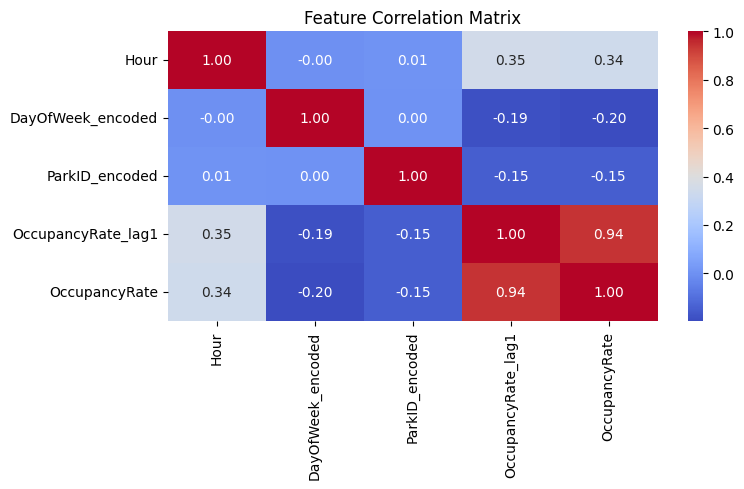

In [9]:
plt.figure(figsize=(8, 5))
sns.heatmap(df_model[features + [target]].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../data/processed/plot_correlation.png')
plt.show()

 Save Prepared Data

In [10]:
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print("All files saved to data/processed/")

All files saved to data/processed/
